
Showing one image per class for: Train
Set: Train, Class: paper, Shape: (300, 300, 3)


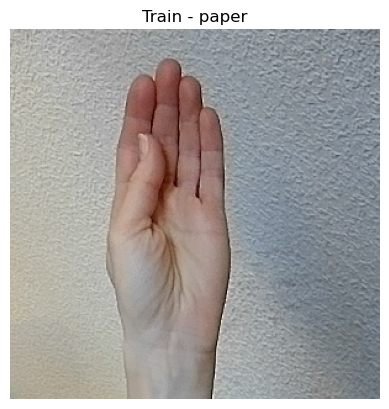

Set: Train, Class: rock, Shape: (300, 300, 3)


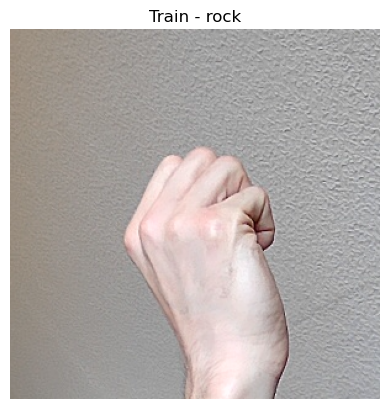

Set: Train, Class: scissors, Shape: (300, 300, 3)


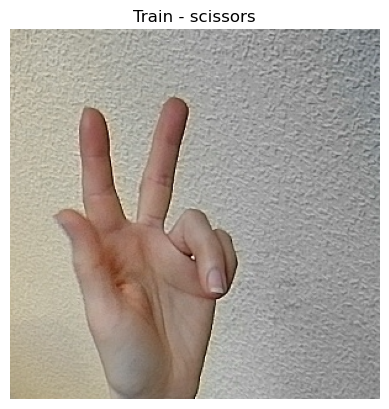


Showing one image per class for: DevTest
Set: DevTest, Class: rock, Shape: (300, 300, 3)


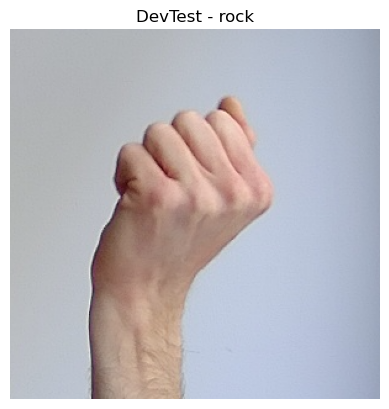

Set: DevTest, Class: scissors, Shape: (300, 300, 3)


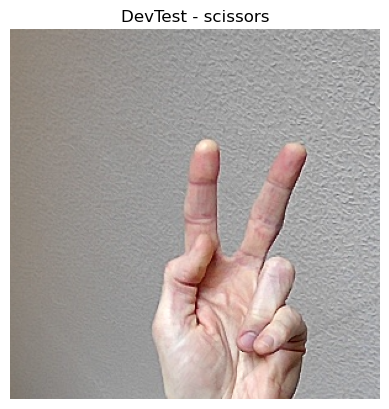

Set: DevTest, Class: paper, Shape: (300, 300, 3)


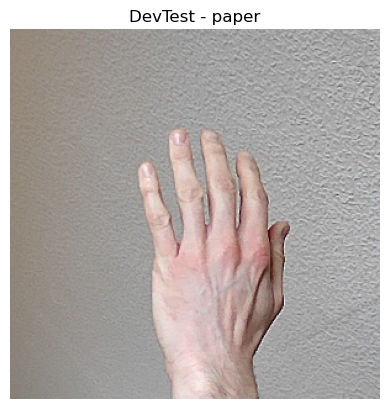


Showing one image per class for: Test
Set: Test, Class: paper, Shape: (300, 300, 3)


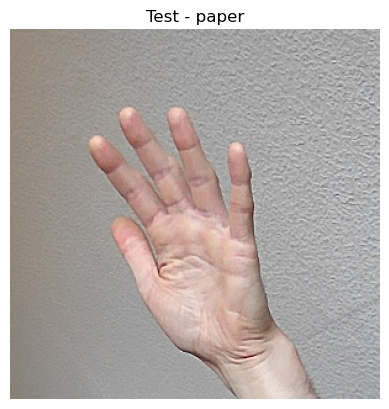

Set: Test, Class: rock, Shape: (300, 300, 3)


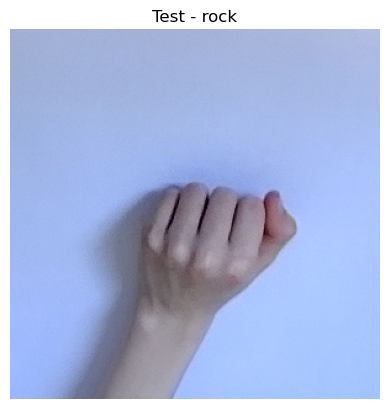

Set: Test, Class: scissors, Shape: (300, 300, 3)


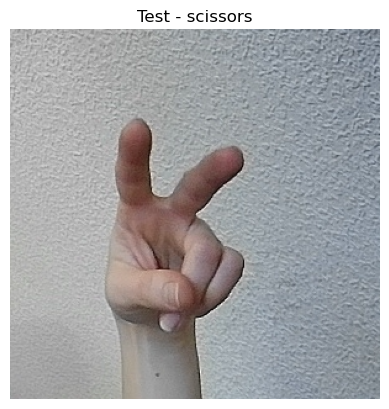


Image counts for Train:
label
paper       544
rock        544
scissors    541
Name: count, dtype: int64

Image counts for DevTest:
label
rock        181
paper       181
scissors    180
Name: count, dtype: int64

Image counts for Test:
label
paper       182
rock        182
scissors    182
Name: count, dtype: int64


In [6]:
#Task 1.1
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

# Base directory containing all folders and CSVs
base_dir = r"C:\Users\rekit\OneDrive\Desktop\Semester 4\Artificial Intelligence For Text And Vision (3420)\assignment-2-RakinRayan"

# Load CSV files
train_df = pd.read_csv(os.path.join(base_dir, "train.csv"))
devtest_df = pd.read_csv(os.path.join(base_dir, "devtest.csv"))
test_df = pd.read_csv(os.path.join(base_dir, "test.csv"))

# Function to show one image per class from a set
def show_one_image_per_class(df, set_name):
    print(f"\nShowing one image per class for: {set_name}")
    shown = set()
    
    for _, row in df.iterrows():
        label = row['label']
        filepath = row['path']
        full_path = os.path.join(base_dir, filepath)
        
        if label not in shown and os.path.exists(full_path):
            img = Image.open(full_path)
            img_np = np.array(img)
            
            print(f"Set: {set_name}, Class: {label}, Shape: {img_np.shape}")
            plt.imshow(img_np)
            plt.title(f"{set_name} - {label}")
            plt.axis('off')
            plt.show()
            
            shown.add(label)

        if len(shown) == 3:
            break

# Function to count number of images per class
def count_images_per_class(df, set_name):
    counts = df['label'].value_counts()
    print(f"\nImage counts for {set_name}:")
    print(counts)

# Show images and counts for all splits
show_one_image_per_class(train_df, "Train")
show_one_image_per_class(devtest_df, "DevTest")
show_one_image_per_class(test_df, "Test")

count_images_per_class(train_df, "Train")
count_images_per_class(devtest_df, "DevTest")
count_images_per_class(test_df, "Test")


In [9]:
import os
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms



# Your dataset base directory
base_dir = r"C:\Users\rekit\OneDrive\Desktop\Semester 4\Artificial Intelligence For Text And Vision (3420)\assignment-2-RakinRayan"

# Transform: Resize to 100x100 and rescale pixel values to [0, 1]
transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor()  # Converts to tensor and rescales pixel values to [0.0, 1.0]
])

# Label-to-index mapping
label_to_idx = {'rock': 0, 'paper': 1, 'scissors': 2}

# Custom Dataset

class RockPaperScissorsDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = os.path.join(self.root_dir, row['path'])
        image = Image.open(img_path).convert('RGB')
        label = label_to_idx[row['label']]

        if self.transform:
            image = self.transform(image)
        return image, label

# CSV paths
train_csv = os.path.join(base_dir, 'train.csv')
devtest_csv = os.path.join(base_dir, 'devtest.csv')
test_csv = os.path.join(base_dir, 'test.csv')

# Dataset instances
train_dataset = RockPaperScissorsDataset(train_csv, base_dir, transform)
devtest_dataset = RockPaperScissorsDataset(devtest_csv, base_dir, transform)
test_dataset = RockPaperScissorsDataset(test_csv, base_dir, transform)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
devtest_loader = DataLoader(devtest_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# OPTIONAL: SANITY CHECK 
images, labels = next(iter(train_loader))
print("Train batch shape:", images.shape)  # Expected: [32, 3, 100, 100]
print("Labels:", labels[:8])
print("Pixel value range: min =", images.min().item(), ", max =", images.max().item())


Train batch shape: torch.Size([32, 3, 100, 100])
Labels: tensor([0, 2, 0, 1, 2, 2, 0, 2])
Pixel value range: min = 0.0 , max = 1.0
